In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# path = 'P:\\Lukas_Gehrke\\NAH\\behavior\\5_single-subject-EEG-analysis'
path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname = 'behavior_all.csv'

df = pd.read_csv(path + fname, delimiter=';')

                     mean       std
hapticProfile                      
baseline         0.430320  0.187625
sound            0.425219  0.201561
sound+vibration  0.566670  0.170550
vibration        0.606495  0.188064


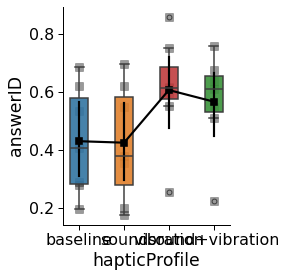

In [13]:
df = df[df.bad_epoch != 1]

df = df.groupby(['hapticProfile','id']).mean().reset_index()

y = 'answerID'
# y = 'AccuracyCm'

print(df.groupby('hapticProfile')[y].agg(['mean','std']))

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(3,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # Plot the orbital period with horizontal boxes
    # sns.boxplot(x=x, y=y, behavior=behavior, whis=[0, 100], width=.3, order= ['intention','involuntary','augmented'], palette=palette, linewidth=1)

    # Add in points to show each observation
    # sns.stripplot(x=x, y=y, behavior=behavior, size=6, palette=palette, linewidth=1, dodge='auto', legend=None)

    # show boxplots
    ax = sns.boxplot(data = df, x = 'hapticProfile', y = y, order= ['baseline','sound','vibration','sound+vibration'], width=.4, hue='hapticProfile', linewidth=1.5)
    for patch in ax.patches: # adapt alpha
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .9))

    # show line connecting means
    ax =  sns.pointplot(data = df, x = 'hapticProfile', y = y, markers="s" ,color = 'black', order= ['baseline','sound','vibration','sound+vibration'])
        
    #  show lines connecting pid means observations    
    # ax = sns.lineplot(data = df, x = 'hapticProfile', y = y, hue = id, palette = sns.color_palette(['black'],8),legend = False,alpha=0.4)
    
    ax = sns.scatterplot(data = df, x = 'hapticProfile', y = y, s=50, legend= True, marker="s",color = 'black',edgecolor = 'black',alpha=0.4)
        
    # ax.invert_yaxis()
    # add_stat_annotation(ax, behavior=behavior_means, x=x, y=y, box_pairs=[("baseline", "ems_random"), ("baseline", "ems_bci"), ('ems_random', 'ems_bci')], test='t-test_paired', text_format='star', loc='outside', verbose=2)

    handles, labels = ax.get_legend_handles_labels()  
    
    #plt.legend(handles[3:6],labels[3:6],frameon=True,loc = 'upper left',labelspacing =0.3)

    # set ylimit
    # ax.set_ylim(-450,150)
    
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    # ax.set_ylabel(ylabel)
    # ax.set_xlabel(xlabel)
    
    plt.show()

# fig.savefig('results/'+title + '_'+'.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig('results/'+title + '_'+'.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig('results/'+title + '_' +'.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

In [14]:
import pymer4 as pymer4
from pymer4.models import Lmer

full_model = Lmer("answerID ~ hapticProfile + (1|id)", data = df)
display(full_model.fit(REML = False))

null_model = Lmer("answerID ~ (1|id)", data = df)
display(null_model.fit(REML = False))

pymer4.stats.lrt([null_model,full_model])

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: answerID~hapticProfile+(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 28	 Groups: {'id': 7.0}

Log-likelihood: 17.716 	 AIC: -23.432

Random effects:

                 Name    Var    Std
id        (Intercept)  0.021  0.144
Residual               0.009  0.096

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.430,0.302,0.559,0.066,11.523,6.567,0.000,***
hapticProfilesound,-0.005,-0.106,0.096,0.052,21.000,-0.099,0.922,
hapticProfilesound+vibration,0.136,0.035,0.237,0.052,21.000,2.644,0.015,*
hapticProfilevibration,0.176,0.075,0.277,0.052,21.000,3.416,0.003,**


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: answerID~(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 28	 Groups: {'id': 7.0}

Log-likelihood: 10.800 	 AIC: -15.601

Random effects:

                 Name    Var    Std
id        (Intercept)  0.019  0.136
Residual               0.018  0.134

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.507,0.395,0.62,0.057,7.0,8.833,0.0,***


,model,npar,AIC,BIC,log-likelihood,deviance,Chisq,Df,P-val,Sig
0,answerID~(1|id),3,-15.600985,-11.604371,10.800492,-21.600985,,,,
1,answerID~hapticProfile+(1|id),6,-23.431780,-15.438553,17.715890,-35.431780,13.830795,3.0,0.003145,**
